<a href="https://colab.research.google.com/github/Ayushkr77/datascience-ai-ml/blob/main/PHASE%201%20%E2%80%94%20Data%20Foundations/Notebooks/DataVisualizationHandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Practice — Data Visualization + Analysis

## Objective

Create a dataset with:

- employee_id  
- department  
- city  
- salary  
- experience  

Then generate:

- Bar chart → Average salary per department  
- Histogram → Salary distribution  
- Scatter plot → Experience vs Salary  
- Boxplot → Salary outliers  
- Correlation heatmap  

After each chart, write 1 insight.

In [1]:
# STEP 1 — Create Dataset

import pandas as pd

data = {
    "employee_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "department": ["IT", "HR", "IT", "Finance", "HR", "Finance", "IT", "HR"],
    "city": ["Delhi", "Mumbai", "Delhi", "Bangalore", "Mumbai", "Delhi", "Bangalore", "Delhi"],
    "salary": [65000, 48000, 72000, 90000, 52000, 85000, 78000, 50000],
    "experience": [2, 1, 4, 8, 3, 7, 5, 2]
}

df = pd.DataFrame(data)


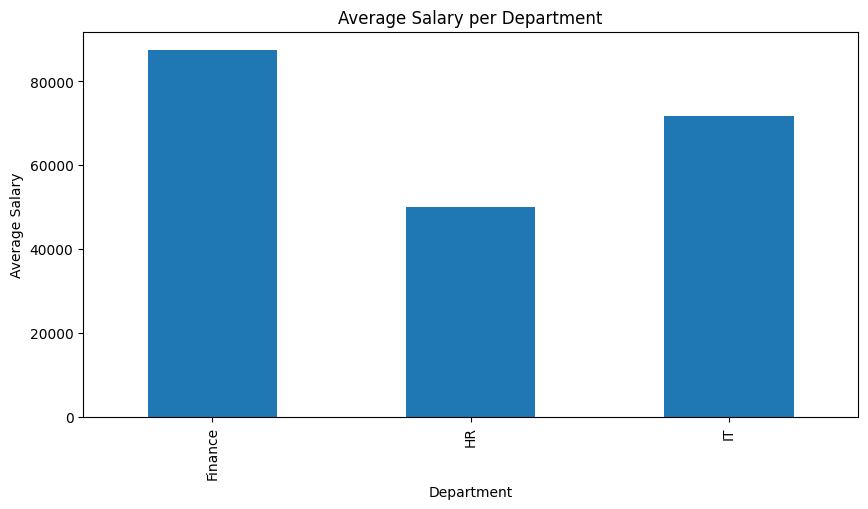

In [13]:
# Bar Chart — Average Salary per Department

# Step 1: Group and calculate mean
avg_salary = df.groupby("department")["salary"].mean()

# Step 2: Import matplotlib
import matplotlib.pyplot as plt

# Step 3: Plot bar chart

plt.figure(figsize=(10,5))   # this line is optional. just used to create a new blank figure
avg_salary.plot(kind="bar")
# or
# plt.bar(avg_salary.index, avg_salary)  # cannot write directly department in x axis as there is no such variable thats why avg_salary.index. can also write plt.bar(avg_salary.index, avg_salary.values)

plt.title("Average Salary per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

# shorter and cleaner way
# df.groupby("department")["salary"].mean().plot(kind="bar")
# plt.show()

# Insight:Finance department has the highest average salary.

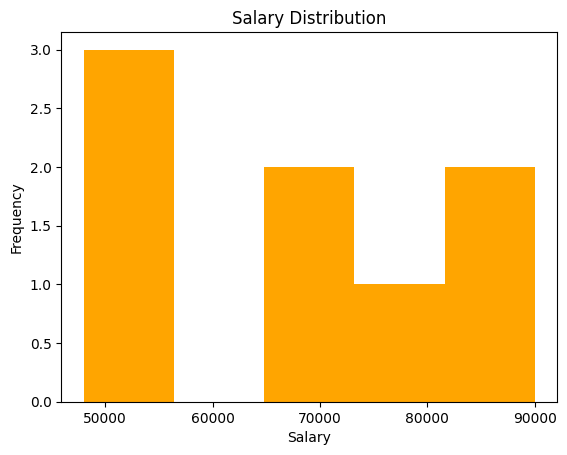

In [18]:
# Histogram — Salary Distribution

plt.figure()

# plt.hist(df["salary"], bins=5)
# or
df["salary"].plot(kind="hist", bins=5, color="orange")   # basic syntax: df["column"].plot(kind="chart_type", **kwargs) kwargs are optional like title,figsize,xlabel,...

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# Insight: Most salaries fall between mid-range values, with fewer extremely high salaries.

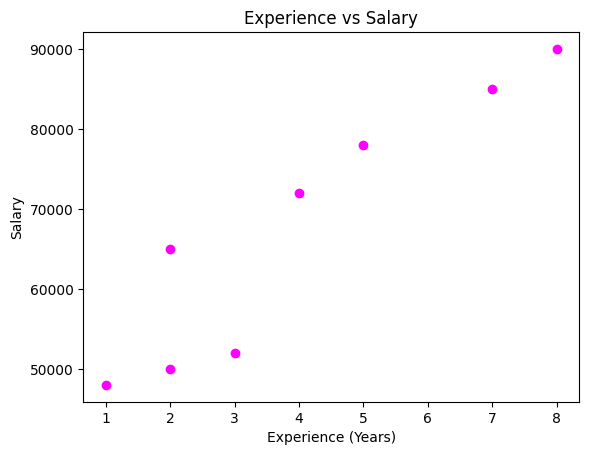

In [28]:
# Scatter Plot — Experience vs Salary

import matplotlib.pyplot as plt

plt.scatter(df["experience"], df["salary"], color="magenta")
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
# OR
# df.plot(kind="scatter", x="experience", y="salary", color="magenta", figsize=(6,4))
# plt.title("Experience vs Salary")

plt.show()

# Insight: Salary generally increases with experience.

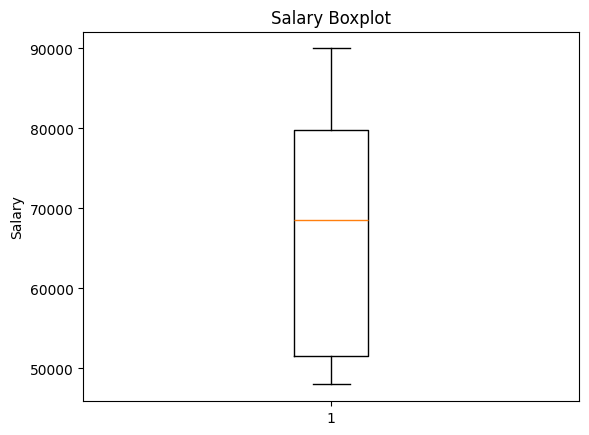

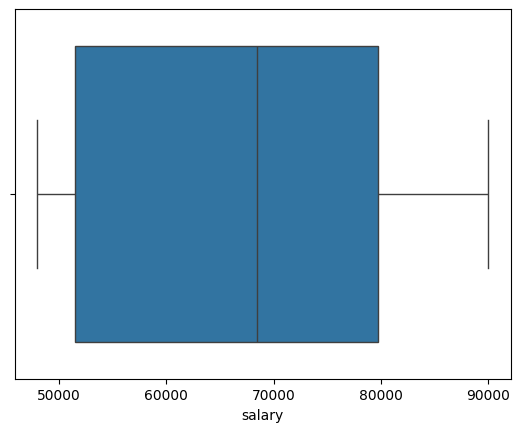

In [31]:
# Boxplot — Detect Salary Outliers

plt.boxplot(df["salary"])
plt.title("Salary Boxplot")
plt.ylabel("Salary")
plt.show()

# or using sns
import seaborn as sns
sns.boxplot(x=df["salary"])
plt.show()

# Insight: There may be one high salary value acting as a potential outlier.

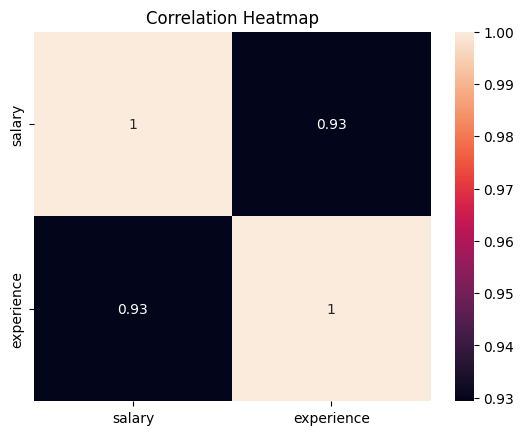

In [33]:
# Correlation Heatmap
# Problem in this

# Step 1: Compute correlation
corr = df[["salary", "experience"]].corr()

# Step 2: Import seaborn
import seaborn as sns

# Step 3: Plot heatmap
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Insight: Salary and experience show positive correlation.

# Skewness — Quick Explanation

## What is Skewness?

Skewness measures the **asymmetry of a distribution** — in other words, whether the data leans more to the left or right.

- If a distribution is perfectly symmetric → **skewness = 0**
- If it leans right (long tail on the right, larger values) → **positively skewed**
- If it leans left (long tail on the left, smaller values) → **negatively skewed**

---

## Visual Understanding

- **Symmetric distribution**  
  Looks like a normal bell curve → skewness ≈ 0  

- **Positively skewed distribution**  
  Most data on the left, tail extends to the right → skewness > 0  

- **Negatively skewed distribution**  
  Most data on the right, tail extends to the left → skewness < 0  

---

## How to Calculate in Pandas

```python
df["salary"].skew()
```

### Interpretation

- `> 0` → Positively skewed  
- `< 0` → Negatively skewed  
- `≈ 0` → Roughly symmetric  

---

## Mean vs Median Relationship

- **Mean > Median** → Positive skew  
- **Mean < Median** → Negative skew  

Reason:  
The mean gets pulled toward the long tail, while the median stays more stable.

---

## Why It Matters

Skewness helps you:

- Detect outliers  
- Decide whether transformation is needed (log transform, etc.)  
- Understand distribution shape before modeling  

Always check distribution shape before applying statistical models.